In [1]:
# Lab 2
# Introduction to deep Learning
# Semester V
# 2026-27
# UIT

# 19/07/2026

In [2]:
#Overview

# First part will apply Multilayer perceptron on a tabular dataset (iris)
# Second part will apply MLP on MNIST-digit

# Aim is to study hyperparameters of MLP and undertsand data analysis, data pre-processing and ML training.

In [3]:
#Load dataset

import tensorflow as tf
import numpy as np
from sklearn.datasets import load_iris

iris = load_iris()

In [4]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [5]:
# Differentiate attributes and labels

x = iris.data
y = iris.target

print(np.shape(x), np.shape(y))
print(x[0], y[0])

(150, 4) (150,)
[5.1 3.5 1.4 0.2] 0


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x = scaler.fit_transform(x)

In [7]:
# Categorical to numerical mapping
from tensorflow.keras.utils import to_categorical

# One-hot encode labels
y = to_categorical(y, 3)
print(np.shape(y))

(150, 3)


In [8]:
# split the dataset
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [9]:
# Build Fully Connected Neural Network
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(16, activation='relu', input_shape=(4,)),
    Dense(8, activation='relu'),
    Dense(3, activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display architecture
model.summary()

C:\Users\silen\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │              80 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │              27 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Train model
history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=8,
    validation_split=0.1,
    verbose=1
)



Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.2500 - loss: 1.4294 - val_accuracy: 0.4167 - val_loss: 1.2228
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2407 - loss: 1.3234 - val_accuracy: 0.4167 - val_loss: 1.1735
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2500 - loss: 1.2389 - val_accuracy: 0.4167 - val_loss: 1.1281
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3056 - loss: 1.1635 - val_accuracy: 0.5000 - val_loss: 1.0884
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3611 - loss: 1.1028 - val_accuracy: 0.5000 - val_loss: 1.0543
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3796 - loss: 1.0456 - val_accuracy: 0.5000 - val_loss: 1.0244
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3981 - loss: 1.0000 - val_accuracy: 0.5000 - val_loss: 0.9999
Epoch 8/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4444 - loss: 0.9536 - val_accuracy: 0.5000 - val_

In [11]:
# Evaluate
loss, accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.8667 - loss: 0.4051
Test Accuracy: 0.8666666746139526


In [12]:
#--------------------------------------MNIST-digit-----------------------------------------------

In [13]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()


(60000, 28, 28) 47040000
(60000,) 60000
(10000, 28, 28) 7840000
(10000,) 10000
label 3
3


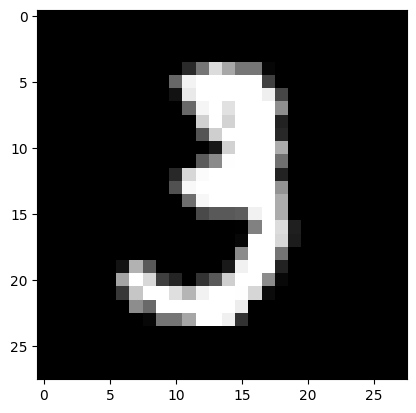

In [14]:
#Know your data

print(np.shape(x_train), np.size(x_train))
print(np.shape(y_train), np.size(y_train))
print(np.shape(x_test), np.size(x_test))
print(np.shape(y_test), np.size(y_test))

i=10
plt.imshow(x_train[i],cmap="gray")
print("label", y_train[i])
print(y_train[i])

In [15]:
#Normalization

train_images = x_train.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255
test_images = x_test.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255

print(np.shape(train_images), np.size(train_images))
print(np.shape(test_images), np.size(test_images))

(60000, 784) 47040000
(10000, 784) 7840000


In [16]:
train_images[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [17]:
#define a model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(512, activation="relu",  input_shape=(784,)),
    Dense(256, activation="relu"),
    Dense(10, activation="softmax")
])

In [18]:
# Display model architecture
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 512)                 │         401,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(optimizer="rmsprop",
loss="sparse_categorical_crossentropy",
metrics=["accuracy"])

In [20]:
#training
model.fit(train_images, y_train, epochs=10, batch_size=256)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9107 - loss: 0.2966
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9679 - loss: 0.1049
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9795 - loss: 0.0664
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9852 - loss: 0.0474
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9890 - loss: 0.0341
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9925 - loss: 0.0248
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9938 - loss: 0.0190
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9959 - loss: 0.0138
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9967 - loss: 0.0104
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9973 - loss: 0.0083


In [21]:
model.evaluate(train_images, y_train)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9983 - loss: 0.0062


[0.006180077325552702, 0.9983000159263611]

In [22]:
model.evaluate(test_images, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9809 - loss: 0.0759


[0.07588844001293182, 0.98089998960495]

In [23]:
# Task 1

# Figure out whether model overfit or not?

# Get training and validation accuracy
train_accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]

# Get training and validation loss
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

# Compare final accuracy
accuracy_difference = train_accuracy[-1] - val_accuracy[-1]

print("Training Accuracy:", train_accuracy[-1])
print("Validation Accuracy:", val_accuracy[-1])

print("Training Loss:", train_loss[-1])
print("Validation Loss:", val_loss[-1])

print("Accuracy Difference:", accuracy_difference)

# Check for overfitting
if accuracy_difference > 0.05 and val_loss[-1] > train_loss[-1]:
    print("\nThe model is overfitting.")
else:
    print("\nThe model is not significantly overfitting.")

Training Accuracy: 0.8148148059844971
Validation Accuracy: 0.75
Training Loss: 0.46231868863105774
Validation Loss: 0.6905404925346375
Accuracy Difference: 0.06481480598449707

The model is overfitting.


In [24]:
#Task 2

#Try different hyperparameters
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical



In [25]:
# Number of layers

model_layers = Sequential([
    Dense(256, activation="relu", input_shape=(784,)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

model_layers.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_layers.fit(
    train_images,
    y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

loss, accuracy = model_layers.evaluate(
    test_images,
    y_test,
    verbose=0
)

print("\nDifferent Number of Layers")
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

Epoch 1/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8924 - loss: 0.3773 - val_accuracy: 0.9602 - val_loss: 0.1410
Epoch 2/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9611 - loss: 0.1336 - val_accuracy: 0.9723 - val_loss: 0.0976
Epoch 3/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9738 - loss: 0.0875 - val_accuracy: 0.9713 - val_loss: 0.0933
Epoch 4/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9806 - loss: 0.0645 - val_accuracy: 0.9765 - val_loss: 0.0803
Epoch 5/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9856 - loss: 0.0485 - val_accuracy: 0.9728 - val_loss: 0.0916
Epoch 6/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9885 - loss: 0.0382 - val_accuracy: 0.9767 - val_loss: 0.0781
Epoch 7/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9906 - loss: 0.0289 - val_accuracy: 0.9817 - val_loss: 0.0707
Epoch 8/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9932 - loss: 0.0226 - val_accuracy: 0

In [26]:
# Activation functions

model_activation = Sequential([
    Dense(256, activation="tanh", input_shape=(784,)),
    Dense(128, activation="tanh"),
    Dense(10, activation="softmax")
])

model_activation.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_activation.fit(
    train_images,
    y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

loss, accuracy = model_activation.evaluate(
    test_images,
    y_test,
    verbose=0
)

print("\nDifferent Activation Function")
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)


Epoch 1/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8932 - loss: 0.3705 - val_accuracy: 0.9510 - val_loss: 0.1754
Epoch 2/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9466 - loss: 0.1833 - val_accuracy: 0.9608 - val_loss: 0.1332
Epoch 3/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9615 - loss: 0.1300 - val_accuracy: 0.9698 - val_loss: 0.1028
Epoch 4/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9706 - loss: 0.0988 - val_accuracy: 0.9733 - val_loss: 0.0953
Epoch 5/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9771 - loss: 0.0777 - val_accuracy: 0.9772 - val_loss: 0.0778
Epoch 6/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9821 - loss: 0.0618 - val_accuracy: 0.9780 - val_loss: 0.0730
Epoch 7/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9858 - loss: 0.0495 - val_accuracy: 0.9773 - val_loss: 0.0735
Epoch 8/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9882 - loss: 0.0415 - val_accu

In [27]:
# learning rate

optimizer = Adam(learning_rate=0.0005)

model_learning_rate = Sequential([
    Dense(256, activation="relu", input_shape=(784,)),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

model_learning_rate.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_learning_rate.fit(
    train_images,
    y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

loss, accuracy = model_learning_rate.evaluate(
    test_images,
    y_test,
    verbose=0
)

print("\nDifferent Learning Rate")
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

Epoch 1/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8719 - loss: 0.4781 - val_accuracy: 0.9475 - val_loss: 0.1910
Epoch 2/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9474 - loss: 0.1856 - val_accuracy: 0.9592 - val_loss: 0.1385
Epoch 3/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9614 - loss: 0.1330 - val_accuracy: 0.9687 - val_loss: 0.1059
Epoch 4/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9714 - loss: 0.1000 - val_accuracy: 0.9712 - val_loss: 0.0958
Epoch 5/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9772 - loss: 0.0798 - val_accuracy: 0.9748 - val_loss: 0.0841
Epoch 6/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9824 - loss: 0.0636 - val_accuracy: 0.9770 - val_loss: 0.0782
Epoch 7/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9848 - loss: 0.0529 - val_accuracy: 0.9778 - val_loss: 0.0768
Epoch 8/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9876 - loss: 0.0438 - val_accurac

In [28]:
#Different Number Of Epoch

model_epochs = Sequential([
    Dense(256, activation="relu", input_shape=(784,)),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

model_epochs.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_epochs.fit(
    train_images,
    y_train,
    epochs=15,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

loss, accuracy = model_epochs.evaluate(
    test_images,
    y_test,
    verbose=0
)

print("\nDifferent Number of Epochs")
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

Epoch 1/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9000 - loss: 0.3568 - val_accuracy: 0.9647 - val_loss: 0.1327
Epoch 2/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9589 - loss: 0.1384 - val_accuracy: 0.9710 - val_loss: 0.0986
Epoch 3/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9723 - loss: 0.0907 - val_accuracy: 0.9733 - val_loss: 0.0858
Epoch 4/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9806 - loss: 0.0637 - val_accuracy: 0.9778 - val_loss: 0.0735
Epoch 5/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9859 - loss: 0.0473 - val_accuracy: 0.9783 - val_loss: 0.0723
Epoch 6/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9889 - loss: 0.0366 - val_accuracy: 0.9808 - val_loss: 0.0662
Epoch 7/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9918 - loss: 0.0274 - val_accuracy: 0.9803 - val_loss: 0.0767
Epoch 8/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9939 - loss: 0.0218 - val_accu

In [29]:
#Different Number Of Epoch

model_epochs = Sequential([
    Dense(256, activation="relu", input_shape=(784,)),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

model_epochs.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_epochs.fit(
    train_images,
    y_train,
    epochs=10,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

loss, accuracy = model_epochs.evaluate(
    test_images,
    y_test,
    verbose=0
)

print("\nDifferent Number of Epochs")
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)


Epoch 1/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9010 - loss: 0.3591 - val_accuracy: 0.9647 - val_loss: 0.1325
Epoch 2/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9613 - loss: 0.1325 - val_accuracy: 0.9723 - val_loss: 0.0994
Epoch 3/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9734 - loss: 0.0901 - val_accuracy: 0.9737 - val_loss: 0.0896
Epoch 4/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9810 - loss: 0.0644 - val_accuracy: 0.9788 - val_loss: 0.0755
Epoch 5/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9859 - loss: 0.0487 - val_accuracy: 0.9787 - val_loss: 0.0758
Epoch 6/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9892 - loss: 0.0365 - val_accuracy: 0.9778 - val_loss: 0.0724
Epoch 7/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9918 - loss: 0.0282 - val_accuracy: 0.9793 - val_loss: 0.0755
Epoch 8/10
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9933 - loss: 0.0235 - val_accur

In [30]:
# Diff Optimizer

model_optimizer = Sequential([
    Dense(256, activation="relu", input_shape=(784,)),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

model_optimizer.compile(
    optimizer="sgd",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_optimizer.fit(
    train_images,
    y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

loss, accuracy = model_optimizer.evaluate(
    test_images,
    y_test,
    verbose=0
)

print("\nDifferent Optimizer")
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)


Epoch 1/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.5599 - loss: 1.7360 - val_accuracy: 0.8003 - val_loss: 1.0996
Epoch 2/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8130 - loss: 0.8506 - val_accuracy: 0.8753 - val_loss: 0.5840
Epoch 3/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8558 - loss: 0.5750 - val_accuracy: 0.8973 - val_loss: 0.4347
Epoch 4/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8748 - loss: 0.4730 - val_accuracy: 0.9095 - val_loss: 0.3665
Epoch 5/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8851 - loss: 0.4190 - val_accuracy: 0.9157 - val_loss: 0.3288
Epoch 6/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8925 - loss: 0.3848 - val_accuracy: 0.9198 - val_loss: 0.3047
Epoch 7/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8978 - loss: 0.3607 - val_accuracy: 0.9230 - val_loss: 0.2865
Epoch 8/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9031 - loss: 0.3425 - val_accuracy

In [31]:
#Loss Function

y_train_onehot = to_categorical(y_train, 10)
y_test_onehot = to_categorical(y_test, 10)

model_loss = Sequential([
    Dense(256, activation="relu", input_shape=(784,)),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

model_loss.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_loss.fit(
    train_images,
    y_train_onehot,
    epochs=20,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

loss, accuracy = model_loss.evaluate(
    test_images,
    y_test_onehot,
    verbose=0
)

print("\nDifferent Loss Function")
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

Epoch 1/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8979 - loss: 0.3619 - val_accuracy: 0.9630 - val_loss: 0.1340
Epoch 2/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9603 - loss: 0.1344 - val_accuracy: 0.9713 - val_loss: 0.1032
Epoch 3/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9738 - loss: 0.0898 - val_accuracy: 0.9800 - val_loss: 0.0772
Epoch 4/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9804 - loss: 0.0654 - val_accuracy: 0.9785 - val_loss: 0.0752
Epoch 5/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9851 - loss: 0.0493 - val_accuracy: 0.9803 - val_loss: 0.0694
Epoch 6/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9886 - loss: 0.0384 - val_accuracy: 0.9792 - val_loss: 0.0716
Epoch 7/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9914 - loss: 0.0296 - val_accuracy: 0.9803 - val_loss: 0.0722
Epoch 8/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9940 - loss: 0.0218 - val_accuracy

In [32]:
#Task 3

# Calculate number of parameters
# Layer 1
weights_1 = 784 * 256
bias_1 = 256

# Layer 2
weights_2 = 256 * 128
bias_2 = 128

# Output layer
weights_3 = 128 * 10
bias_3 = 10


# Calculate parameters for each layer
layer_1 = weights_1 + bias_1
layer_2 = weights_2 + bias_2
layer_3 = weights_3 + bias_3

# Calculate total parameters
total_parameters = layer_1 + layer_2 + layer_3


print("Layer 1 parameters:", layer_1)
print("Layer 2 parameters:", layer_2)
print("Output layer parameters:", layer_3)

print("Total parameters:", total_parameters)

# Check with Keras
model_layers.summary()

Layer 1 parameters: 200960
Layer 2 parameters: 32896
Output layer parameters: 1290
Total parameters: 235146


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 728,288 (2.78 MB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 485,526 (1.85 MB)

In [33]:
#Task 4

# Repeat above task fro fashion_MNIST dataset

import tensorflow as tf
import numpy as np

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam


# Load Fashion-MNIST dataset

(x_train_f, y_train_f), (x_test_f, y_test_f) = fashion_mnist.load_data()


# Check dataset shape

print("Training images:", x_train_f.shape)
print("Training labels:", y_train_f.shape)

print("Testing images:", x_test_f.shape)
print("Testing labels:", y_test_f.shape)

Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images: (10000, 28, 28)
Testing labels: (10000,)


In [34]:
# Flatten images

train_fashion = x_train_f.reshape(60000, 784)
test_fashion = x_test_f.reshape(10000, 784)


# Normalize values

train_fashion = train_fashion.astype("float32") / 255
test_fashion = test_fashion.astype("float32") / 255


print("After flattening:")
print("Training:", train_fashion.shape)
print("Testing :", test_fashion.shape)

After flattening:
Training: (60000, 784)
Testing : (10000, 784)


In [35]:
# Create Fashion-MNIST model

fashion_model = Sequential([
    Dense(256, activation="relu", input_shape=(784,)),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])


# Compile model

fashion_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# Display model

fashion_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                     │ (None, 256)                 │         200,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_29 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_30 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [36]:
# Train the model

fashion_history = fashion_model.fit(
    train_fashion,
    y_train_f,
    epochs=20,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8040 - loss: 0.5684 - val_accuracy: 0.8453 - val_loss: 0.4330
Epoch 2/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8612 - loss: 0.3891 - val_accuracy: 0.8572 - val_loss: 0.3951
Epoch 3/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8755 - loss: 0.3450 - val_accuracy: 0.8717 - val_loss: 0.3514
Epoch 4/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8857 - loss: 0.3134 - val_accuracy: 0.8770 - val_loss: 0.3625
Epoch 5/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8891 - loss: 0.3012 - val_accuracy: 0.8745 - val_loss: 0.3366
Epoch 6/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8970 - loss: 0.2800 - val_accuracy: 0.8785 - val_loss: 0.3311
Epoch 7/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9019 - loss: 0.2663 - val_accuracy: 0.8845 - val_loss: 0.3210
Epoch 8/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9068 - loss: 0.2546 - val_accu

In [37]:
# Evaluate the model

test_loss, test_accuracy = fashion_model.evaluate(
    test_fashion,
    y_test_f,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.3413391411304474
Test Accuracy: 0.8921999931335449


In [38]:
# Check for overfitting

train_acc = fashion_history.history["accuracy"]
val_acc = fashion_history.history["val_accuracy"]

train_loss = fashion_history.history["loss"]
val_loss = fashion_history.history["val_loss"]


# Get final values

final_train_acc = train_acc[-1]
final_val_acc = val_acc[-1]

final_train_loss = train_loss[-1]
final_val_loss = val_loss[-1]


print("Training Accuracy:", final_train_acc)
print("Validation Accuracy:", final_val_acc)

print("Training Loss:", final_train_loss)
print("Validation Loss:", final_val_loss)


# Calculate accuracy difference

accuracy_gap = final_train_acc - final_val_acc

print("Accuracy Difference:", accuracy_gap)


# Check overfitting

if accuracy_gap > 0.05 and final_val_loss > final_train_loss:
    print("\nThe Fashion-MNIST model is overfitting.")
else:
    print("\nThe Fashion-MNIST model is not significantly overfitting.")

Training Accuracy: 0.9386851787567139
Validation Accuracy: 0.8970000147819519
Training Loss: 0.16712579131126404
Validation Loss: 0.3172852396965027
Accuracy Difference: 0.04168516397476196

The Fashion-MNIST model is not significantly overfitting.
